# Лекция 03. Функции

В этой лекции рассматривается понятие функции, а так же импортирование модулей и подключение к файлам

## Оглавление:
* [03.01. Определение функции](#0)
    * [Создание функции](#1)
    * [Параметры функции](#2)
    * [Области видимости (scope)](#3)    
        * [Операторы global и nonlocal](#4)   
    * [Значение аргументов по умолчанию](#5)   
    * [Ключевые аргументы](#6)   
    * [Переменное число параметров](#7)   
    * [lambda-функции](#8)   
* [03.02. Модули](#9)
* [03.03. Чтение и запись в файлы](#10)    
* [Практика](#11)    
* [Домашнее задание](#12)

<a class="anchor" id="0"></a>
Функция - это обособленный участок кода, который можно вызывать, обратившись к нему по имени, которым он был назван (подпрограмма); объект, принимающий аргументы и возвращающий значение.

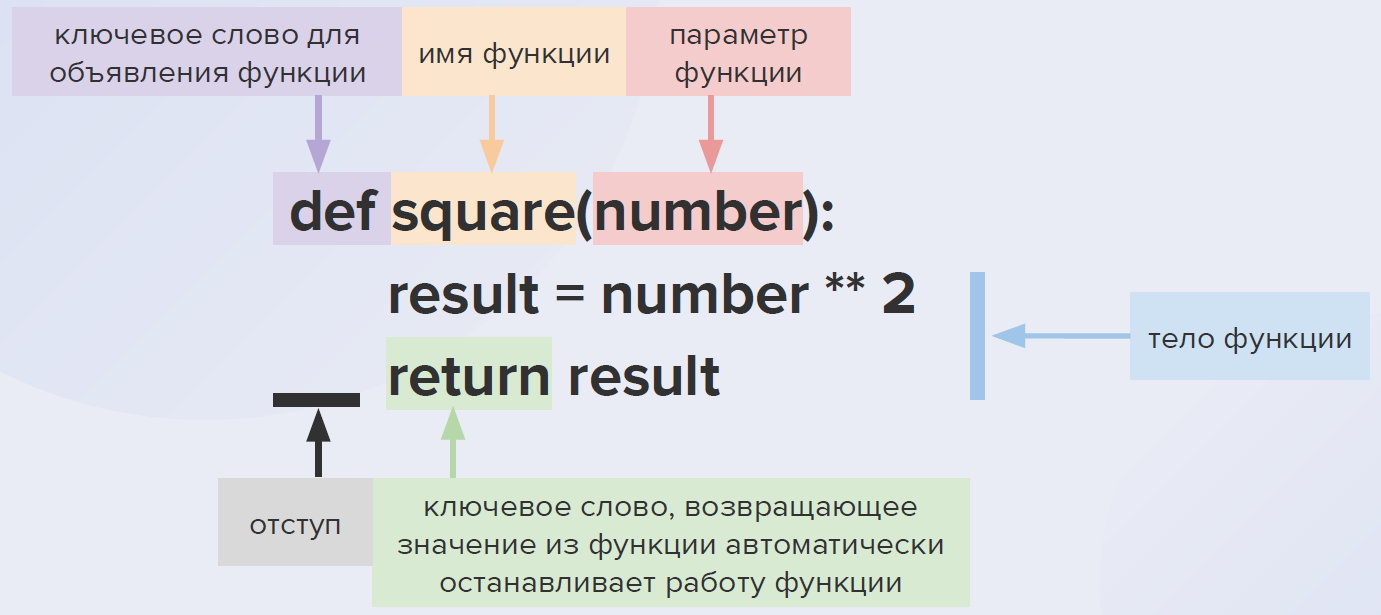

### Создание функции <a class="anchor" id="1"></a>

In [1]:
# создаем функцию
def square(number):
    result = number ** 2
    return result

print(square(10))
my_square = square(10)
print(my_square)

100
100


In [2]:
help(len)
# ?len

Help on built-in function len in module builtins:

len(obj, /)
    Return the number of items in a container.



**Docstring** - встроенное средство документирования модулей, функций, классов и методов.

In [3]:
# пишем docstring к своей функции
def square(number):
    """
    this is my function

    """
    result = number ** 2
    return result

In [4]:
?square

### Параметры функции: <a class="anchor" id="2"></a>
* Может принимать более 1 параметра или не принимать вообще
* Можно указывать значения по умолчанию

In [9]:
# 1. Функция без параметров
def square_2():
    user_input = int(input('Введите число'))
    result = user_input ** 2
    return result
square_2()

Введите число3


9

In [63]:
# 2. Функция с двумя параметрамим
def power(number, number_2):
    result = number ** number_2
    return result
power(4, 2)

16

In [64]:
# 3. Функция с параметром по умолчанию
def power(number, number_2=2):
    result = number ** number_2
    return result
power(4)

16

In [65]:
# 4. Если не указан return, функция всегда возвращает None!
def square_3(number):
    result = number ** 2
    print(result)
#     return None
#     return
square_3(5)
# print(square_3(5))

25


### Области видимости (scope) <a class="anchor" id="3"></a>

Определяет контекст объекта, в рамках которого его можно использовать.
Есть 3 типа области видимости:
* Global Scope - Глобальный контекст, доступен для любой функции в программе
* Local Scope - Контекст внутри функции
* Nonlocal Scope - Среднее между первыми двумя. Нелокальные области видимости встречаются, когда вы определяете функции внутри функций.

Если Python не может найти нужную переменную в локальной области видимости, то тогда (и только тогда) он будет искать ее в области видимости уровня выше.

Пример контекстов

In [69]:
# Упражнение 01. Задаем 2 параметра вне функции, они будут глобальными. 
# Такие же локальные параметры действуют только внутри функции
number = 5
power = 3

def power_2():
    number = 6
    power = 2
    return number ** power

print(power_2())
print(number ** power)

36
125


In [67]:
# Упражнение 02. Задаем 2 параметра вне функции, потом переназначаем 1 из них внутри функции
number = 5
power = 3

def power_2():
    number = 6
    return number ** power

print(power_2())
print(number ** power)

216
125


In [70]:
# Упражнение 03. Задаем 2 параметра вне функции, в функции они работают, т.к. глобальные
number = 5
power = 3

def power_2():
    return number ** power

power_2()

125

In [71]:
# Упражнение 04. Параметры заданы внутри функции, поэтому обращение вне ее выдает ошибку
def power_2():
    number = 6
    power = 2
    some_number = 1
    return number ** power
print(some_number)

NameError: name 'some_number' is not defined

### Операторы global и nonlocal <a class="anchor" id="4"></a>
* global - Задать глобальную переменную в локальном контексте
* nonlocal -Изменить переменную в области видимости более высокого уровня)

In [15]:
# Упражнение 05. Глобальная переменная перезаписана в локальном контексте

name = 'James'
def say_hi():
#     global name
    name = 'Oleg'
    print('Hello', name)

say_hi()

print(name)

Hello Oleg
James


In [72]:
# Упражнение 06. Локальную переменную превращаем в более высокий уровень
def say_hi():
    name = 'Oleg'
    def get_name():
        nonlocal name
        name = input('Введите имя')
        return name
    get_name()
    print('Hello', name)

say_hi()

Введите имявывыв
Hello вывыв


### Значение аргументов по умолчанию <a class="anchor" id="5"></a>

In [77]:
def say(message, times = 1):
    print(message * times)
say('Привет') # по умолчанию повторяем 1 раз
say('Мир', 5)

Привет
МирМирМирМирМир


Значения по умолчанию нужно прописывать в конце списка параметров

In [83]:
def func(a, b=5):
    return a, b
# Работает

In [87]:
def func(a=5, b):
    return a, b
# Выдает ошибку

SyntaxError: non-default argument follows default argument (<ipython-input-87-206fae2ce429>, line 1)

### Ключевые аргументы <a class="anchor" id="6"></a>

Для функции с большим числом параметров, когда при её вызове требуется указать только некоторые из них, значения этих параметров могут задаваться по их имени. В этом случае для передачи аргументов  функции используется имя (ключ) вместо позиции (как было до сих пор).

Преимущества такого подхода: 
1. Использование функции становится легче, поскольку нет необходимости отслеживать порядок аргументов; 
2. Можно задавать значения только некоторым избранным аргументам, при условии, что остальные параметры имеют значения аргумента по умолчанию.

In [91]:
def func(a, b=5, c=10):
    print('a равно', a, ', b равно', b, ', а c равно', c)

# a получает значение 3, b получает значение 7,  c - получает значение по умолчанию, равное 10. 
func(3, 7) 
# a получает значение 25 по позиции аргумента.
# После этого параметр c получает значение 24 по имени, т.е. как ключевой параметр.
# Переменная b получает значение по умолчанию, равное 5.
func(25, c=24)
# При третьем обращении func(c=50, a=100) мы используем ключевые аргументы для всех указанных значений.
func(c=50, a=100)

a равно 3 , b равно 7 , а c равно 10
a равно 25 , b равно 5 , а c равно 24
a равно 100 , b равно 5 , а c равно 50


### Переменное число параметров <a class="anchor" id="7"></a>

Для определения функции, которая принимает любое кол-во параметров используют звездочки

In [94]:
# Определяем функцию
def total(a=5, *numbers, **phonebook):
    print('a', a)
    #проход по всем элементам кортежа
    for single_item in numbers:
        print('single_item', single_item)
    #проход по всем элементам словаря
    for first_part, second_part in phonebook.items():
        print(first_part,second_part)

print(total(10,1,2,3,Jack=1123,John=2231,Inge=1560))

a 10
single_item 1
single_item 2
single_item 3
Jack 1123
John 2231
Inge 1560
None


Как это работает:
Когда мы объявляем параметр со звёздочкой (например, \*param\), все позиционные аргументы начиная с этой позиции и до конца будут собраны в кортеж под именем param.

Аналогично, когда мы объявляем параметры с двумя звёздочками (\**param\) ,все ключевые аргументы начиная с этой позиции и до конца будут собраны в словарь под именем param

args kwargs - еще примеры

In [29]:
def api_request(*params):
    date_start = params[0]
    date_end = params[1]
    print(params)
    print(date_start, date_end)

In [30]:
api_request('2019-01-01', '2019-01-31', ';sdfsdgsdg', 'sdgsdgsdg', 'sdgsdg')

('2019-01-01', '2019-01-31', ';sdfsdgsdg', 'sdgsdgsdg', 'sdgsdg')
2019-01-01 2019-01-31


In [31]:
def api_requets(**params):
    return params

In [32]:
api_requets(a=1, b=2, c=3)

{'a': 1, 'b': 2, 'c': 3}

In [33]:
def api_request(**params):
    date_start = params['date_start']
    date_end = params['date_end']
    
    print(date_start, date_end)

In [34]:
api_request(date_end='2019-01-31', date_start='2019-01-01')

2019-01-01 2019-01-31


### lambda-функции <a class="anchor" id="8"></a>

In [17]:
# lambda-функции
func = lambda x, y: x + y
print(func(1, 2))

3


In [3]:
nums = [1, 2, 3, 4, 5]

In [1]:
# Подсчет четные не четные
even_numbers = lambda x: x % 2 == 0
odd_even_numbers = lambda x: 'even' if x % 2 == 0 else 'odd'

In [4]:
for num in nums:
    print(odd_even_numbers(num))

odd
even
odd
even
odd


Функция map - принимает на вход функцию и значения. 
Делает так, что для каждого значения аргумента функция будет применена отдельно

In [26]:
# функция map
list(map(odd_even_numbers, nums))

['odd', 'even', 'odd', 'even', 'odd']

In [22]:
def square(x):
    return x**2

In [23]:
for i in map(square, range(100, 105)):
    print(i)
    if i==10: break

10000
10201
10404
10609
10816


In [28]:
# nums = [1, 2, 3, 4, 5]
# for num in nums:
#     print(num)

nums = [1, 2, 3, 4, 5]
for i, num in enumerate(nums):
    print(i,num)

0 1
1 2
2 3
3 4
4 5


## Модули <a class="anchor" id="9"></a>

In [60]:
import math

In [61]:
math.factorial(5)

120

In [62]:
import numpy

In [63]:
numpy.zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [64]:
import numpy as np
np.zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [65]:
from numpy import zeros
zeros(10)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

Попробовать импортировать собственную функцию (сохранить под расширением .py)

In [107]:
# Ранее сделали простейший модуль, сохранили его в py
# Помните, что модуль должен находиться либо в том же каталоге, что и программа, 
# в которую мы импортируем его, либо в одном из каталогов, указанных в sys.path.

import mymodule
mymodule.sayhi()
print ('Версия', mymodule.__version__)

Привет! Это говорит мой модуль.
Версия 0.1


## Чтение и запись в файлы  <a class="anchor" id="10"></a>

**Вариант 1 подключения к файлу:**
* Первый аргумент: Путь к файлу
    * Если откырть данный файл в jupyter, то можно не прописывать полный путь.
    * По умолчанию: где лежит исполняемый файл jupyter.exe
* Второй аргумент: как читаем файл
* **'r'** - открыть файл для чтения
* **'w'** - очистить файл и открыть для записи новых данных
* **'a'** - добавить строчки к концу файла

In [108]:
f = open('adult.csv', 'r')
for line in f:
    print(line)
    break
    
f.close() 

age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income



Конструкция **with** автоматически закрывает файл после работы с ним

In [36]:

# прочитать содержимое файла в список
with open('adult.csv', 'r') as f:
    content = f.readlines()

# content[:5]
content[1:6:2]

['25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K\n',
 '28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K\n',
 '18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K\n']

In [37]:
# прочитать большой файл построчно
with open('adult.csv') as f:
    for line in f:
        print(line)
        
        break

age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income



In [38]:
# подготовим файл для работы
i = 0
with open('adult.csv', 'r') as f:
    for line in f:
        print(line.strip().split(',')) # удаляем служебные символы и пробелы, разделяем по запятой
        
        i = i + 1
        if i > 5:
            break

['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
['25', 'Private', '226802', '11th', '7', 'Never-married', 'Machine-op-inspct', 'Own-child', 'Black', 'Male', '0', '0', '40', 'United-States', '<=50K']
['38', 'Private', '89814', 'HS-grad', '9', 'Married-civ-spouse', 'Farming-fishing', 'Husband', 'White', 'Male', '0', '0', '50', 'United-States', '<=50K']
['28', 'Local-gov', '336951', 'Assoc-acdm', '12', 'Married-civ-spouse', 'Protective-serv', 'Husband', 'White', 'Male', '0', '0', '40', 'United-States', '>50K']
['44', 'Private', '160323', 'Some-college', '10', 'Married-civ-spouse', 'Machine-op-inspct', 'Husband', 'Black', 'Male', '7688', '0', '40', 'United-States', '>50K']
['18', '?', '103497', 'Some-college', '10', 'Never-married', '?', 'Own-child', 'White', 'Female', '0', '0', '30', 'United-States', '<=50K']


## Практика. Классификация жителей по возрасту  <a class="anchor" id="11"></a>

Хотим классифицировать жителей в файле по возрастам:
* до 18 лет - children 
* 19-65 - young
* старше 65 - retiree

Шаг 00. Подключаемся к файлу

In [39]:
i = 0
#  открываем файл, распаковывыем: первый элемент в age, остальные во второй элемент
with open('adult.csv', 'r') as f:
    for line in f:
        age, *other_columns = line.strip().split(',')
        
        if i > 0:
            print(age)
        
        i += 1
        if i > 5:
            break

25
38
28
44
18


Шаг 01. Добавим классификацию возрастов

In [40]:
i = 0
with open('adult.csv', 'r') as f:
    for line in f:
        age, *other_columns = line.strip().split(',')
#       Добавляем условия
        if i > 0:
            if int(age) <= 18:
                age_group = 'children'

            elif int(age) <= 60:
                age_group = 'young'

            else:
                age_group = 'retiree'
                
            print(age, age_group)
        
        i += 1
        if i > 10:
            break

25 young
38 young
28 young
44 young
18 children
34 young
29 young
63 retiree
24 young
55 young


Что тут нехорошо:
* сложно потестировать все случаи (в нашем цикле нужных случаев может и не оказаться)
* наш цикл стал довольно громоздким, а мы только начали
* эта классификация может потребоваться еще в 100500 местах кода
* данные могут быть кривыми и скрипт будет падать с ошибкой

Условия вычисления возрастной группы:
1. В строке 15 столбцов
2. Столбец с возрастом первый по счету
3. Возраст должен быть целым числом в адекватных пределах
4. Могут добавиться еще требования, о которых мы пока не знаем

Шаг 02. Формируем функцию

In [112]:
def age_is_correct(age, lower_age=0, upper_age=120):
    """
    Проверка корректности возраста age по следующим правилам:
    1. Целое число
    2. В адекватных пределах
    
    Возвращает True или False. Пример
    age_is_correct(15)
    True
    
    age_is_correct(121)
    False
    
    age_is_correct(-5)
    False
    """
    
    if str.isnumeric(age):
        if lower_age <= int(age) <= upper_age:
            return True
    
    return False

Функция расчета кол-ва столбцов

In [42]:
def number_of_columns(line, separator=','):
    """Возвращает количество столбцов в строке line с разделителем separator"""
    
    return len(line.split(separator))

Проверяем корректность кол-ва столбцов (=15)

In [43]:
def line_is_correct(line):
    """
    Проверка строки на корректность. Проверяются условия:
    1. В строке 15 столбцов (пригодится с упражнения)
    2. Столбец с возрастом первый по счету
    3. Возраст должен быть целым числом в адекватных пределах
    """
    age = line.strip().split(',')[0]
    
    if number_of_columns(line) == 15:
        if age_is_correct(age):
            return True
    
    return False

Шаг 03. Добавляем функции проверки в наш цикл

In [45]:
i = 0
with open('adult.csv', 'r') as f:
    for line in f:
        
        if line_is_correct(line):
            age, *other_columns = line.strip().split(',')
            if int(age) <= 18:
                age_group = 'children'

            elif int(age) <= 60:
                age_group = 'young'

            else:
                age_group = 'retiree'

            print(age, age_group)
        
        i += 1
        if i > 10:
            break

25 young
38 young
28 young
44 young
18 children
34 young
29 young
63 retiree
24 young
55 young


Шаг 04. Вынесем классификацию возраста в отдельную функцию

In [46]:
def age_classification(age):
    """
    Возвращает возрастную категорию для возраста age (можно передать как строку).
    Классификация категорий:
        - до 18 лет - children 
        - 19-60 - young
        - старше 65 - retiree
    
    Пример
    age_classification('18')
    'children'
    
    age_classification(65)
    'retiree'
    """
    
    if int(age) <= 18:
        return 'children'
    if int(age) <= 65:
        return 'young'
    if int(age) > 65:
        return 'retiree'
    return 'boom'

In [47]:
age_classification(61)

'young'

**Шаг 05. Итоговая функция вычисления возраста**

In [48]:
def main():
    with open('adult.csv', 'r') as f:
        for line in f:
            if line_is_correct(line):
                age, *_ = line.strip().split(',')
                print(age, age_classification(age))

In [59]:
main()

25 young
38 young
28 young
44 young
18 children
34 young
29 young
63 young
24 young
55 young
65 young
36 young
26 young
58 young
48 young
43 young
20 young
43 young
37 young
40 young
34 young
34 young
72 retiree
25 young
25 young
45 young
22 young
23 young
54 young
32 young
46 young
56 young
24 young
23 young
26 young
65 young
36 young
22 young
17 children
20 young
65 young
44 young
36 young
29 young
20 young
28 young
39 young
54 young
52 young
56 young
18 children
39 young
21 young
22 young
38 young
21 young
63 young
34 young
42 young
33 young
30 young
39 young
26 young
33 young
47 young
41 young
41 young
19 young
46 young
43 young
55 young
46 young
30 young
21 young
46 young
17 children
41 young
69 retiree
50 young
20 young
45 young
23 young
24 young
44 young
31 young
43 young
20 young
55 young
24 young
41 young
59 young
49 young
33 young
59 young
34 young
20 young
25 young
49 young
59 young
20 young
51 young
33 young
22 young
58 young
52 young
36 young
41 young
28 young
19 young
18 

22 young
47 young
34 young
35 young
20 young
36 young
52 young
38 young
33 young
18 children
38 young
56 young
30 young
35 young
60 young
20 young
18 children
19 young
53 young
18 children
44 young
57 young
36 young
40 young
33 young
19 young
40 young
20 young
47 young
41 young
47 young
23 young
49 young
37 young
67 retiree
24 young
39 young
29 young
22 young
26 young
33 young
23 young
37 young
30 young
41 young
23 young
47 young
24 young
39 young
33 young
25 young
40 young
67 retiree
55 young
69 retiree
34 young
52 young
22 young
47 young
45 young
23 young
41 young
32 young
57 young
34 young
44 young
46 young
60 young
46 young
32 young
44 young
43 young
48 young
55 young
24 young
65 young
51 young
42 young
36 young
19 young
24 young
52 young
28 young
42 young
25 young
53 young
35 young
20 young
38 young
46 young
18 children
58 young
41 young
66 retiree
38 young
29 young
39 young
44 young
26 young
27 young
29 young
29 young
47 young
62 young
29 young
52 young
27 young
53 young
29 young

57 young
18 children
24 young
36 young
42 young
32 young
35 young
40 young
26 young
41 young
50 young
20 young
36 young
25 young
62 young
22 young
52 young
52 young
48 young
70 retiree
41 young
21 young
39 young
29 young
28 young
31 young
23 young
54 young
73 retiree
29 young
22 young
57 young
41 young
39 young
25 young
74 retiree
45 young
18 children
24 young
45 young
32 young
53 young
50 young
35 young
24 young
32 young
21 young
42 young
37 young
53 young
34 young
29 young
55 young
29 young
70 retiree
26 young
51 young
58 young
23 young
27 young
17 children
29 young
26 young
31 young
29 young
22 young
28 young
28 young
20 young
58 young
23 young
34 young
32 young
19 young
18 children
35 young
21 young
20 young
49 young
34 young
37 young
36 young
44 young
39 young
36 young
53 young
34 young
24 young
40 young
47 young
19 young
18 children
32 young
21 young
27 young
58 young
29 young
34 young
45 young
43 young
63 young
26 young
42 young
21 young
36 young
44 young
18 children
69 retiree


37 young
36 young
21 young
26 young
81 retiree
52 young
48 young
34 young
47 young
37 young
37 young
42 young
23 young
37 young
45 young
28 young
89 retiree
54 young
23 young
20 young
50 young
35 young
37 young
31 young
24 young
52 young
18 children
35 young
51 young
41 young
57 young
22 young
37 young
74 retiree
56 young
33 young
31 young
41 young
26 young
59 young
23 young
35 young
50 young
52 young
31 young
37 young
48 young
50 young
30 young
24 young
57 young
49 young
23 young
20 young
52 young
56 young
57 young
20 young
43 young
41 young
45 young
36 young
62 young
19 young
24 young
19 young
20 young
32 young
44 young
53 young
45 young
39 young
55 young
30 young
39 young
23 young
28 young
42 young
35 young
39 young
29 young
21 young
35 young
42 young
28 young
57 young
59 young
50 young
37 young
20 young
46 young
28 young
32 young
20 young
38 young
36 young
30 young
35 young
30 young
56 young
30 young
64 young
21 young
17 children
49 young
37 young
52 young
55 young
24 young
23 youn

58 young
62 young
41 young
46 young
53 young
33 young
58 young
30 young
27 young
32 young
19 young
22 young
56 young
33 young
36 young
29 young
32 young
33 young
20 young
51 young
52 young
64 young
33 young
38 young
30 young
67 retiree
37 young
55 young
25 young
41 young
31 young
51 young
75 retiree
53 young
36 young
47 young
67 retiree
29 young
32 young
42 young
41 young
46 young
48 young
55 young
68 retiree
49 young
62 young
30 young
56 young
37 young
22 young
56 young
53 young
53 young
51 young
41 young
34 young
24 young
40 young
23 young
28 young
53 young
52 young
33 young
28 young
45 young
40 young
60 young
24 young
50 young
44 young
19 young
36 young
33 young
52 young
51 young
44 young
19 young
49 young
17 children
20 young
53 young
25 young
48 young
27 young
21 young
29 young
47 young
48 young
38 young
19 young
37 young
37 young
39 young
35 young
33 young
56 young
23 young
25 young
47 young
32 young
24 young
32 young
41 young
32 young
37 young
39 young
66 retiree
18 children
23 

...

47 young
42 young
43 young
37 young
36 young
27 young
54 young
48 young
29 young
29 young
37 young
55 young
67 retiree
51 young
35 young
41 young
64 young
23 young
49 young
38 young
62 young
62 young
70 retiree
45 young
20 young
38 young
50 young
40 young
30 young
52 young
28 young
62 young
31 young
40 young
34 young
53 young
42 young
26 young
51 young
49 young
43 young
42 young
31 young
26 young
50 young
35 young
37 young
53 young
20 young
31 young
28 young
46 young
21 young
41 young
30 young
66 retiree
37 young
74 retiree
46 young
51 young
33 young
30 young
47 young
49 young
53 young
24 young
54 young
32 young
45 young
46 young
37 young
48 young
25 young
28 young
44 young
58 young
27 young
69 retiree
38 young
47 young
30 young
46 young
27 young
19 young
18 children
24 young
32 young
38 young
19 young
28 young
39 young
38 young
42 young
31 young
46 young
53 young
21 young
48 young
46 young
30 young
24 young
32 young
30 young
57 young
56 young
27 young
38 young
19 young
61 young
49 you

21 young
39 young
37 young
40 young
38 young
47 young
20 young
35 young
62 young
32 young
42 young
32 young
27 young
53 young
28 young
26 young
47 young
23 young
70 retiree
41 young
43 young
65 young
40 young
64 young
40 young
43 young
50 young
19 young
32 young
32 young
42 young
41 young
30 young
20 young
45 young
42 young
24 young
43 young
28 young
35 young
36 young
38 young
32 young
50 young
34 young
35 young
30 young
61 young
27 young
61 young
18 children
31 young
31 young
20 young
35 young
51 young
43 young
18 children
55 young
59 young
21 young
22 young
60 young
49 young
21 young
61 young
64 young
63 young
27 young
23 young
41 young
18 children
40 young
55 young
17 children
34 young
24 young
30 young
29 young
52 young
57 young
38 young
43 young
61 young
38 young
51 young
40 young
41 young
19 young
28 young
59 young
32 young
31 young
30 young
54 young
33 young
20 young
27 young
32 young
35 young
27 young
40 young
34 young
34 young
38 young
28 young
65 young
61 young
18 children
35

37 young
21 young
32 young
48 young
62 young
21 young
28 young
19 young
20 young
41 young
29 young
47 young
43 young
20 young
29 young
51 young
40 young
26 young
30 young
36 young
68 retiree
42 young
41 young
43 young
20 young
43 young
53 young
45 young
39 young
31 young
23 young
69 retiree
38 young
37 young
18 children
41 young
30 young
23 young
26 young
37 young
25 young
33 young
37 young
31 young
27 young
35 young
28 young
59 young
42 young
50 young
27 young
32 young
27 young
43 young
46 young
41 young
59 young
20 young
57 young
46 young
45 young
29 young
23 young
46 young
55 young
58 young
38 young
29 young
57 young
26 young
42 young
61 young
31 young
43 young
47 young
51 young
23 young
24 young
25 young
22 young
38 young
48 young
33 young
46 young
18 children
52 young
46 young
28 young
37 young
23 young
45 young
17 children
56 young
38 young
81 retiree
22 young
43 young
31 young
42 young
66 retiree
50 young
31 young
35 young
21 young
36 young
33 young
36 young
37 young
50 young
55

35 young
21 young
21 young
41 young
61 young
24 young
21 young
36 young
37 young
69 retiree
49 young
55 young
21 young
18 children
26 young
20 young
46 young
23 young
48 young
36 young
42 young
41 young
45 young
52 young
22 young
20 young
27 young
36 young
34 young
38 young
20 young
47 young
21 young
33 young
31 young
61 young
46 young
55 young
19 young
39 young
61 young
28 young
28 young
61 young
61 young
54 young
50 young
37 young
17 children
56 young
31 young
32 young
28 young
34 young
33 young
42 young
64 young
29 young
41 young
45 young
48 young
44 young
34 young
40 young
45 young
23 young
51 young
24 young
57 young
23 young
34 young
36 young
56 young
42 young
45 young
38 young
29 young
54 young
40 young
29 young
35 young
47 young
51 young
28 young
58 young
24 young
46 young
57 young
22 young
28 young
17 children
23 young
19 young
66 retiree
38 young
39 young
39 young
47 young
39 young
22 young
36 young
32 young
29 young
43 young
51 young
42 young
32 young
34 young
51 young
38 you

31 young
82 retiree
23 young
40 young
35 young
24 young
21 young
27 young
29 young
40 young
17 children
27 young
34 young
18 children
39 young
34 young
44 young
18 children
39 young
28 young
30 young
60 young
58 young
49 young
61 young
27 young
59 young
52 young
42 young
27 young
41 young
35 young
50 young
36 young
21 young
38 young
46 young
59 young
55 young
49 young
59 young
38 young
22 young
28 young
47 young
59 young
37 young
33 young
34 young
35 young
55 young
18 children
48 young
48 young
70 retiree
27 young
43 young
32 young
62 young
18 children
50 young
38 young
18 children
46 young
26 young
44 young
32 young
25 young
55 young
55 young
25 young
40 young
29 young
60 young
45 young
43 young
24 young
34 young
47 young
24 young
47 young
18 children
50 young
22 young
49 young
41 young
68 retiree
62 young
25 young
24 young
44 young
32 young
49 young
68 retiree
25 young
47 young
35 young
37 young
57 young
37 young
34 young
46 young
21 young
26 young
45 young
17 children
36 young
33 yo

# Домашние задания <a class="anchor" id="12"></a>

## Задание 1

Дан список вида:

In [50]:
data = [
    [13, 25, 23, 34],
    [45, 32, 44, 47],
    [12, 33, 23, 95],
    [13, 53, 34, 35]
]

Напишите функцию, которая возвращает сумму элементов на диагонали. Т. е. 13 + 32 + 23 + 35.

In [52]:
# Создаем функцию суммирования по диагонали
def diag_sum(data):
    i = 0
    diag_sum = 0
    for i in range(len(data)):
        diag_sum += data[i][i]
    return diag_sum
# Выводим результат
diag_sum(data)

103

In [53]:
# Стандартный вариант работает для квадратных матриц. Переделаем для прямоугольных.
def diag_sum_rectangle(data):
    # Выбираем максимальное измерение
    min_size = min(len(data),len(data[0]))
    i = 0
    diag_sum = 0
    for i in range(min_size):
        diag_sum += data[i][i]
    return diag_sum

In [54]:
# Выводим вертикальный прямоугольник
data2 = [
    [13, 25, 23, 34],
    [45, 32, 44, 47],
    [12, 33, 55, 95],
    [12, 33, 23, 95],
    [12, 33, 23, 95],
    [12, 33, 23, 95],
    [12, 33, 23, 95],
    [13, 53, 34, 35]
]
print(diag_sum_rectangle(data2))
# Выводим горизонтальный прямоугольник
data3 = [
    [13, 25, 23, 34, 44, 47, 44, 78],
    [45, 32, 44, 47, 23, 34, 44, 44],
    [12, 33, 55, 95, 44, 47, 23, 33]
]
print(diag_sum_rectangle(data3))

195
100


## Задание 2

Дан список чисел, часть из которых имеют строковый тип или содержат буквы. Напишите функцию, которая возвращает сумму квадратов элементов, которые могут быть числами.

In [55]:
data = [1, '5', 'abc', 20, '2']

In [56]:
def int_sum_func(data):
    int_sum = 0
    for element in data:
        if str(element).isdigit():
            int_sum += int(element)**2
    return int_sum  
int_sum_func(data)

430

## Задание 3

Напишите функцию, возвращающую сумму первых n чисел Фибоначчи.

In [57]:
def fibo_sum(n):
    fibo_list = []
    fibo_sum = 0
    def fibo_numbers(n):
        if n == 0:
            return 0
        elif n == 1:
            return 1
        else:
            return fibo_numbers(n-1) + fibo_numbers(n-2)    
    for i in range(0, n + 1):
        fibo_list.append(fibo_numbers(i))
    for j in range(0, n + 1):
        fibo_sum += fibo_list[j]
    return fibo_list, fibo_sum   

print(fibo_sum(7))

([0, 1, 1, 2, 3, 5, 8, 13], 33)


## Задание 4

Дан набор данных об обучении студентов на курсе программирования, который содержит: 
1. имя
2. фамилию 
3. пол 
4. наличие у студента опыта в программировании 
5. набор оценок за домашние работы 
6. оценку за итоговую работу.

Напишите программу, которая будет принимать команду от пользователя и возвращать соотвествующий результат.
Список команд: 
1 - вывести на экран среднюю оценку за все ДЗ по группе и вывести на экран среднюю оценку за экзамен по группе;
2 - вывести среднюю оценку за ДЗ и за экзамен по группе в разрезе пола студентов
3 - вывести среднюю оценку за ДЗ и за экзамен в разрезе наличия опыта в программировании у студентов.

Прогрмма должна быть полностью декомпозирована на функции (кроме объявления функций и вызова итоговой функции в реализации ничего быть не должно).

In [58]:
students_list = [
    {'name': 'Василий', 'surname': 'Теркин', 'sex': 'м', 'program_exp': True, 'grade': [8, 8, 9, 10, 9], 'exam': 9},
    {'name': 'Мария', 'surname': 'Павлова', 'sex': 'ж', 'program_exp': True, 'grade': [7, 8, 9, 7, 9], 'exam': 8},
    {'name': 'Ирина', 'surname': 'Андреева', 'sex': 'ж', 'program_exp': True, 'grade': [10, 9, 8, 10, 10], 'exam': 10},
    {'name': 'Татьяна', 'surname': 'Сидорова', 'sex': 'ж', 'program_exp': True, 'grade': [7, 8, 8, 9, 8], 'exam': 8},
    {'name': 'Иван', 'surname': 'Васильев', 'sex': 'ж', 'program_exp': True, 'grade': [9, 8, 9, 6, 9], 'exam': 10},
    {'name': 'Роман', 'surname': 'Золотарев', 'sex': 'ж', 'program_exp': False, 'grade': [8, 9, 9, 6, 9], 'exam': 10}
]

In [59]:
# Раздел 01. Формируем функции с выбором всех вариантов:

# Шаг 01.01. Задаем список список оценок за домашнее задание
def grade_list():
    grade_list = []
    for element_list in students_list:
        for element in element_list['grade']:
            grade_list.append(element)
    return grade_list

# Шаг 01.02. Задаем список список оценок за экзамен
def exam_list():
    exam_list = []
    for element in students_list:
        exam_list.append(element['exam'])
    return exam_list

# Шаг 01.03. Выводим обобщенный вариант для вывода без фильтров
def var_all():
    result_exam = round(sum(exam_list()) / len(exam_list()), 2)
    result_grade = round(sum(grade_list()) / len(grade_list()), 2)

# Шаг 01.04.Вывод результатов
    return "ДЗ: " , result_grade,"Экзамены: ", result_exam

In [60]:
# Раздел 02. Формируем функции с выбором по фильтрам:

# Шаг 02.01. Задаем список список оценок за домашнее задание
def grade_list_filter(filter_name, filter_value):
    filter_list = []
    for element_list in students_list:
        if element_list[filter_name] == filter_value:
            for element in element_list['grade']:
                filter_list.append(element)
    return filter_list           

# Шаг 02.02. Задаем список список оценок за экзамен
def exam_list_filter(filter_name, filter_value):
    filter_list = []
    for element in students_list:
        if element[filter_name] == filter_value:
            filter_list.append(element['exam'])
    return filter_list

# Шаг 02.03. Выводим обобщенный вариант для вывода без фильтров
def var_filter(filter_name, filter_value):
    result_exam = round(sum(exam_list_filter(filter_name,filter_value)) / len(exam_list_filter(filter_name,filter_value)),2)
    result_grade = round(sum(grade_list_filter(filter_name,filter_value)) / len(grade_list_filter(filter_name,filter_value)),2)

# Шаг 02.04.Вывод результатов
    return "ДЗ: ", result_grade,"Экзамены: ", result_exam

In [61]:
# Раздел 03. Формируем функцию с выбором вариантов ввода:
def input_func(input_code):
    if input_code == 1:
        print("Данные по средним оценкам по всей группе")
        print(var_all())
    elif input_code == 2:
        print("Данные по средним оценкам в зависимости от пола")
        print("Средняя оценка среди женщин составляет: ")
        print(var_filter("sex", "ж"))
        print("Средняя оценка среди мужчин составляет: ")
        print(var_filter("sex", "м"))          
    elif input_code == 3:
        print("Данные по средним оценкам в зависимости от опыта в программировании")
        print("Средняя оценка среди имеющих опыт в программировании составляет: ")
        print(var_filter("sex", "ж"))
        print("Средняя оценка среди не имеющих опыт в программировании составляет: ")
        print(var_filter("sex", "м"))    
    else:
        print("Неправильная команда")
    return input_code

In [62]:
# Раздел 04. Вывод результатов:
input_func(int(input()))

2
Данные по средним оценкам в зависимости от пола
Средняя оценка среди женщин составляет: 
('ДЗ: ', 8.36, 'Экзамены: ', 9.2)
Средняя оценка среди мужчин составляет: 
('ДЗ: ', 8.8, 'Экзамены: ', 9.0)


2